In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)


In [2]:
df = pd.read_csv("dataset_limpio.csv")

X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [4]:
%%time
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],   # Manhattan y Euclidiana
}

hyperband = HalvingGridSearchCV(
    pipe,
    param_grid,
    resource="n_samples",   # ← obligatorio para KNN
    factor=3,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

hyperband.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(hyperband.best_params_)


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 2747
max_resources_: 24724
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 2747
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 1
n_candidates: 7
n_resources: 8241
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 2
n_candidates: 3
n_resources: 24723
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores hiperparámetros encontrados:
{'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
CPU times: user 618 ms, sys: 200 ms, total: 819 ms
Wall time: 1min 37s


In [5]:
y_pred = hyperband.predict(X_test)

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.50      0.03      0.06        29
        muon       0.00      0.00      0.00        80
      photon       0.88      0.72      0.79        50
       track       0.98      1.00      0.99      6022

    accuracy                           0.98      6181
   macro avg       0.59      0.44      0.46      6181
weighted avg       0.96      0.98      0.97      6181



/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


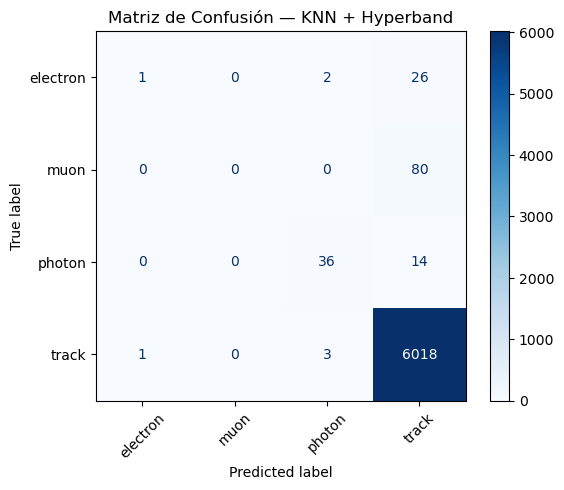

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — KNN + Hyperband")
plt.show()


/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/lib/python3/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


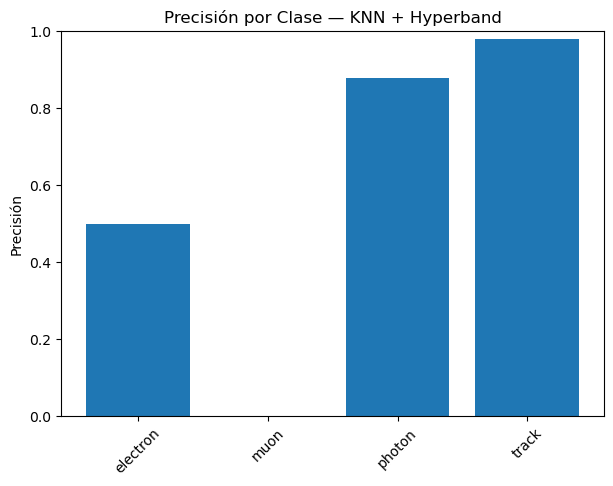

In [7]:
report = classification_report(
    y_test, y_pred, target_names=classes, output_dict=True
)

precisiones = [report[c]["precision"] for c in classes]

plt.figure(figsize=(7,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por Clase — KNN + Hyperband")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


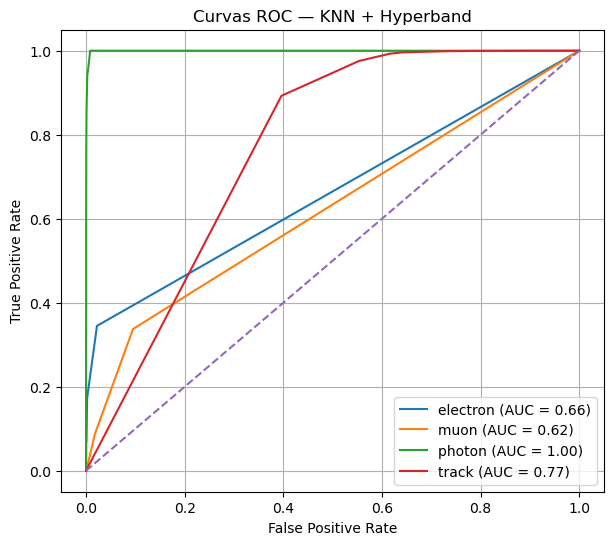

In [8]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_score = hyperband.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — KNN + Hyperband")
plt.legend()
plt.grid()
plt.show()


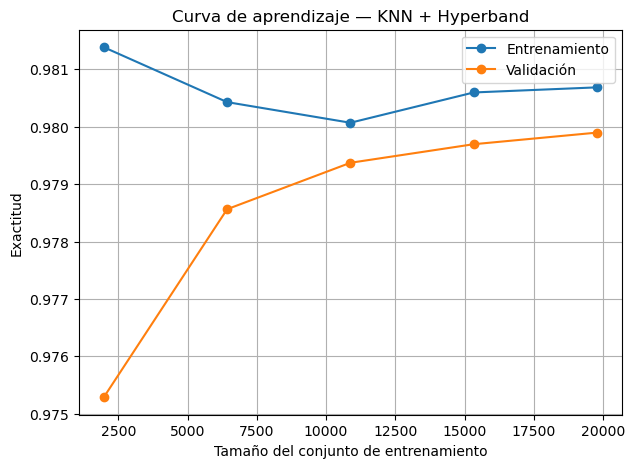

In [9]:
train_sizes, train_scores, test_scores = learning_curve(
    hyperband.best_estimator_,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — KNN + Hyperband")
plt.legend()
plt.grid()
plt.show()


## SIN TRACKS

In [10]:
df = pd.read_csv("dataset_limpio_notracks.csv")

X = df.drop(columns=["particle_type"])
y = df["particle_type"]

# Codificar labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [11]:
%%time
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],   # Manhattan y Euclidiana
}

hyperband = HalvingGridSearchCV(
    pipe,
    param_grid,
    resource="n_samples",   # ← obligatorio para KNN
    factor=3,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

hyperband.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(hyperband.best_params_)


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 70
max_resources_: 635
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 20
n_resources: 70
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 1
n_candidates: 7
n_resources: 210
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 2
n_candidates: 3
n_resources: 630
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores hiperparámetros encontrados:
{'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'uniform'}
CPU times: user 333 ms, sys: 23.2 ms, total: 356 ms
Wall time: 1.22 s


In [12]:
y_pred = hyperband.predict(X_test)

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred, target_names=classes))


=== Reporte de clasificación ===
              precision    recall  f1-score   support

    electron       0.71      0.34      0.47        29
        muon       0.82      0.95      0.88        80
      photon       0.96      1.00      0.98        50

    accuracy                           0.86       159
   macro avg       0.83      0.76      0.77       159
weighted avg       0.84      0.86      0.84       159



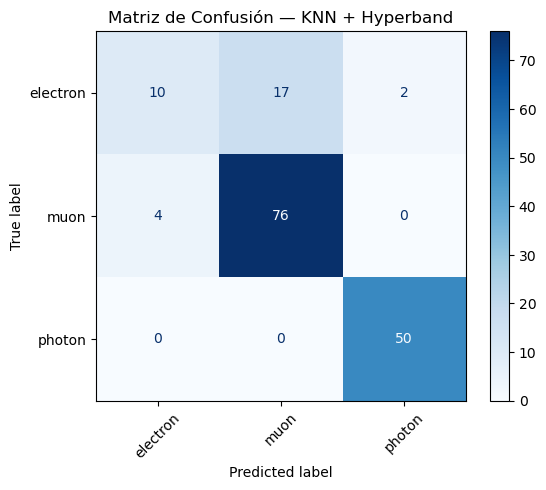

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión — KNN + Hyperband")
plt.show()


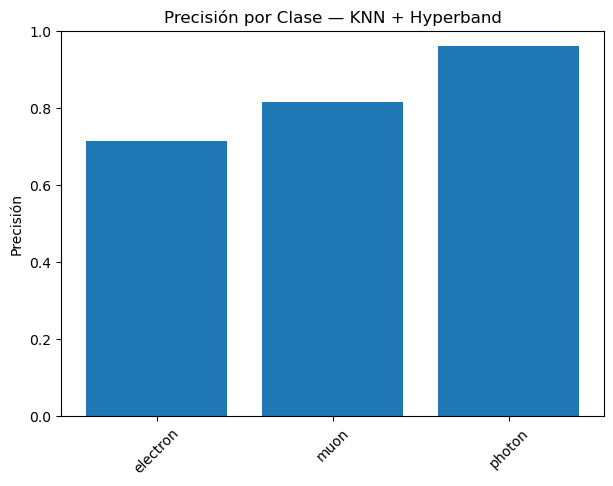

In [14]:
report = classification_report(
    y_test, y_pred, target_names=classes, output_dict=True
)

precisiones = [report[c]["precision"] for c in classes]

plt.figure(figsize=(7,5))
plt.bar(classes, precisiones)
plt.ylabel("Precisión")
plt.title("Precisión por Clase — KNN + Hyperband")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


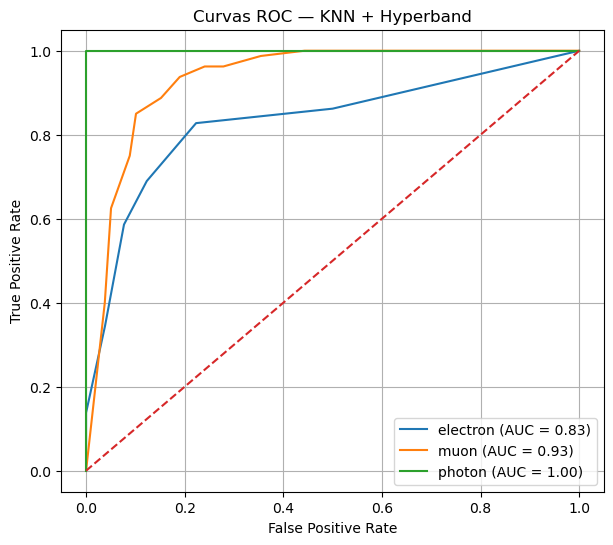

In [15]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(classes)))
y_score = hyperband.predict_proba(X_test)

plt.figure(figsize=(7,6))

for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — KNN + Hyperband")
plt.legend()
plt.grid()
plt.show()



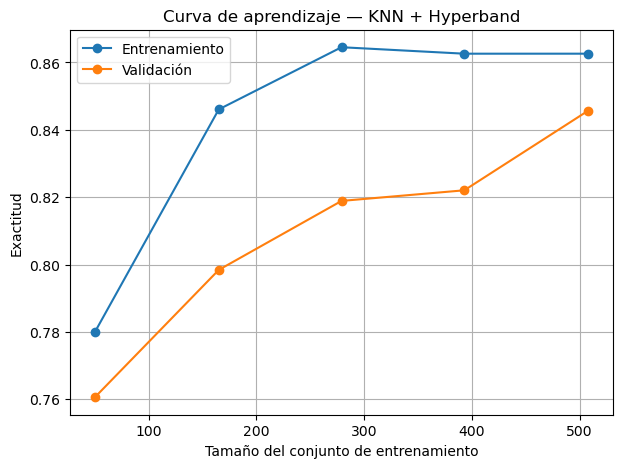

In [16]:
train_sizes, train_scores, test_scores = learning_curve(
    hyperband.best_estimator_,
    X_train,
    y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, test_mean, marker="o", label="Validación")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Exactitud")
plt.title("Curva de aprendizaje — KNN + Hyperband")
plt.legend()
plt.grid()
plt.show()
